---
# 1. Carregamento do dataset + Tratamento inicial

In [1]:
# ================================
# 1. Upload do arquivo no Colab
# ================================
from google.colab import files
uploaded = files.upload()

# O Colab salva o arquivo no diretório atual.
# Pegamos automaticamente o nome do arquivo enviado:
import pandas as pd

nome_arquivo = list(uploaded.keys())[0]
print("Arquivo carregado:", nome_arquivo)

# ================================
# 2. Carregar dataset
# ================================
df = pd.read_csv(nome_arquivo)

# ================================
# 3. Renomear colunas para o padrão do sistema
# ================================
df = df.rename(columns={
    "job_title": "cargo",
    "experience_level": "nivel_experiencia",
    "employment_type": "tipo_contrato",
    "work_models": "modalidade",
    "salary_in_usd": "salario_usd",
    "employee_residence": "pais_residencia",
    "company_location": "pais_empresa",
    "company_size": "porte_empresa",
    "work_year": "ano"
})

# ================================
# 4. Limpeza básica
# ================================
df["cargo"] = df["cargo"].astype(str).str.strip()
df["modalidade"] = df["modalidade"].astype(str).str.strip()
df["nivel_experiencia"] = df["nivel_experiencia"].astype(str).str.strip()

# ================================
# 5. Visualizar primeiras linhas
# ================================
df.head()

Saving data_science_salaries.csv to data_science_salaries.csv
Arquivo carregado: data_science_salaries.csv


,cargo,nivel_experiencia,tipo_contrato,modalidade,ano,pais_residencia,salary,salary_currency,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


---
# 2. Funções do Sistema (v3 – Pandas)

In [2]:
import os

# Criar a pasta se não existir
os.makedirs("sistema", exist_ok=True)

# Conteúdo do arquivo funcoes.py
conteudo = """
import pandas as pd

def filtrar_por_cargo(df, cargo):
    return df[df["cargo"].str.contains(cargo, case=False, na=False)]

def salario_medio_por_nivel(df):
    return df.groupby("nivel_experiencia")["salario_usd"].mean().sort_values()

def salario_medio_por_modalidade(df):
    return df.groupby("modalidade")["salario_usd"].mean().sort_values()

def salario_medio_por_pais(df):
    return df.groupby("pais_residencia")["salario_usd"].mean().sort_values(ascending=False)

def vagas_por_cargo(df):
    return df["cargo"].value_counts()

def salario_medio_por_ano(df):
    return df.groupby("ano")["salario_usd"].mean()

def modalidade_por_ano(df):
    return df.groupby(["ano", "modalidade"]).size().unstack(fill_value=0)
"""

# Criar o arquivo
with open("sistema/funcoes.py", "w") as f:
    f.write(conteudo)

print("Arquivo sistema/funcoes.py criado com sucesso!")

Arquivo sistema/funcoes.py criado com sucesso!


---
# 3. Pergunta de Negócio 5 — Evolução temporal



**Pergunta:** Como os salários médios variaram de 2020 a 2024? Houve mudanças significativas na modalidade de trabalho (mais remoto, menos remoto) no período?

### 🔹 Variação do salário médio entre 2020 e 2024:





<Axes: title={'center': 'Evolução do salário médio (2020–2024)'}, xlabel='ano'>

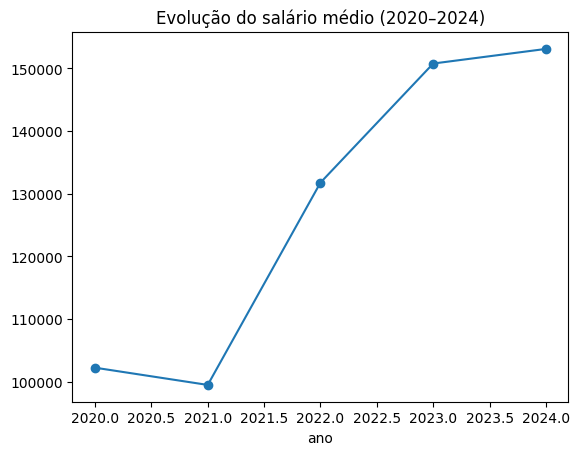

In [3]:

# ================================
# 1. Importar a função e apresentar o gráfico da evolução
# ================================

from sistema.funcoes import salario_medio_por_ano

salarios_ano = salario_medio_por_ano(df)
salarios_ano.plot(kind="line", marker="o", title="Evolução do salário médio (2020–2024)")

### 🔹 Evolução das modalidades de trabalho ao longo do tempo:

<Axes: title={'center': 'Modalidade de trabalho ao longo dos anos'}, xlabel='ano'>

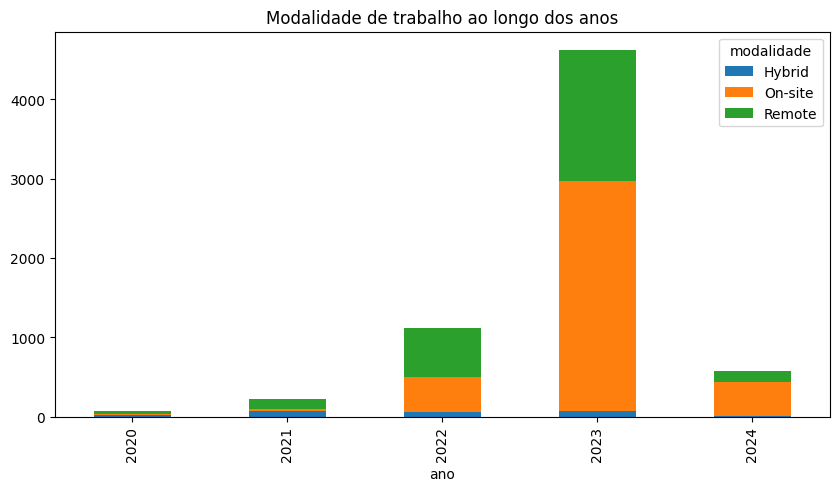

In [4]:
# ================================
# 1. Importar a função e apresentar o gráfico da evolução
# ================================

from sistema.funcoes import modalidade_por_ano

modalidade_ano = modalidade_por_ano(df)
modalidade_ano.plot(kind="bar", stacked=True, figsize=(10,5), title="Modalidade de trabalho ao longo dos anos")

➡️ **Resposta:** O salário médio cresce de forma consistente entre 2020 e 2024. Entre 2020 e 2022, o trabalho remoto dominou amplamente (efeito pandemia). A partir de 2023, a modalidade presencial voltou a crescer e ultrapassou o remoto. Isso indica uma mudança estrutural no mercado pós-pandemia, com empresas retomando o modelo presencial.